# Tokamak Plasma Monitor Lasers
##### Carter Halpin      

##### PHY 400: Lasers and Optomechanics Final Project

In [1]:
#| "tags": [ "hide-input",]
%matplotlib widget
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt
from ipywidgets import *

plt.style.use('dark_background')

fontsize = 14
mpl.rcParams.update(
    {
        "text.usetex": False,
        "figure.figsize": (9, 6),
        # "figure.autolayout": True,
        # "font.family": "serif",
        # "font.serif": "georgia",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
    }
)

### What is a Tokamak?
1. Most promising option for achieving commercial fusion energy
2. Magnetic confinement of plasma in the shape of a torus
3. Large coils that create field in the toroidal and poloidal directions
4. First conceptualized by soviet physicists Andrei Sakharov and Igor Tamm in 1951
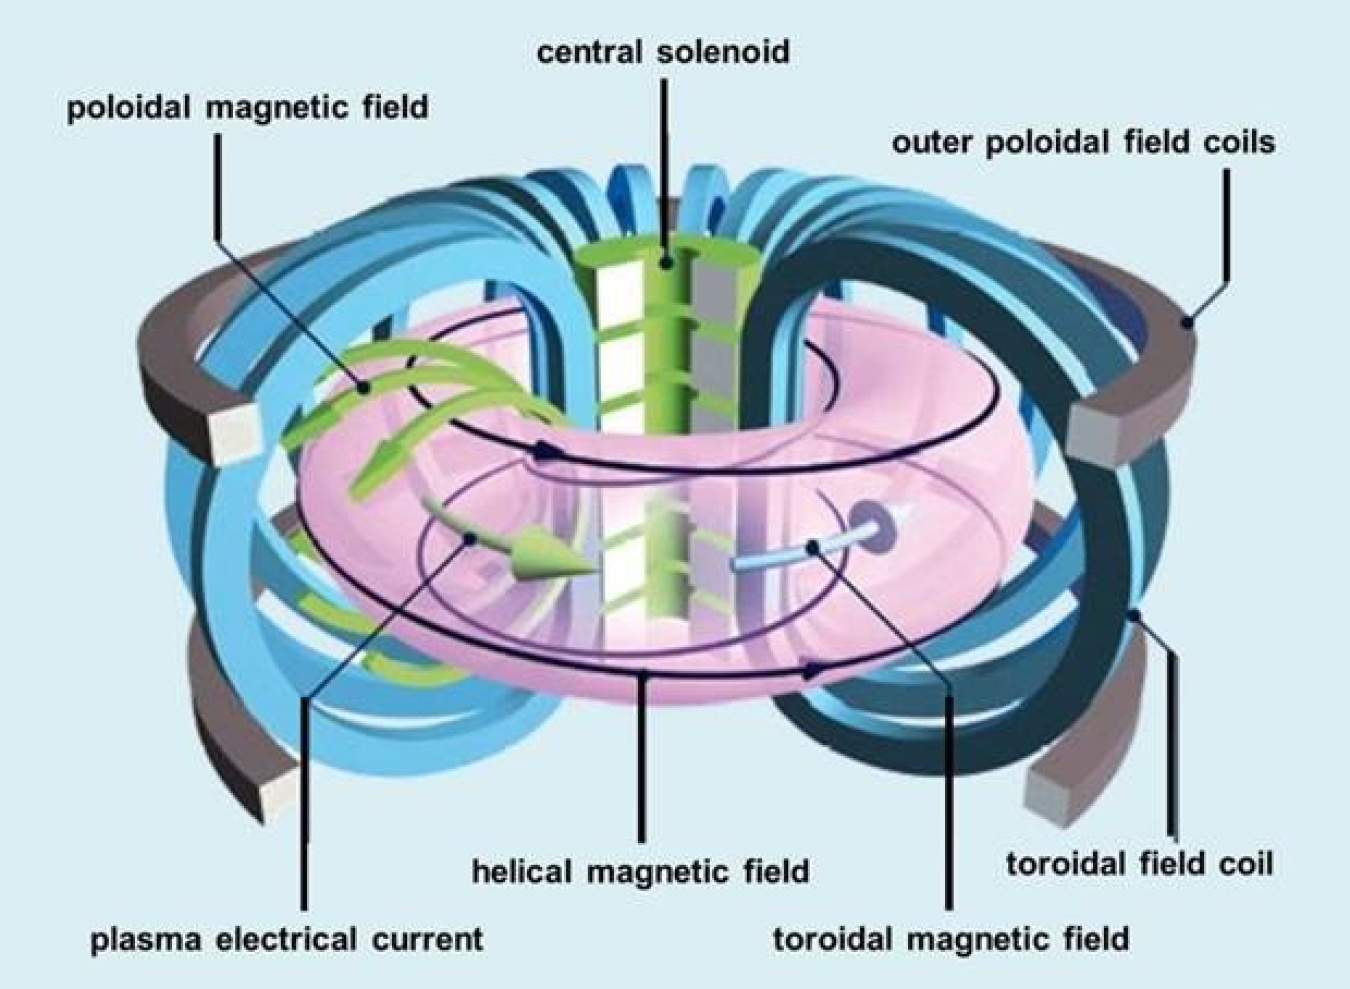

### Why lasers for plasma monitoring?
1. Reactor must be closely monitored to keep the hot plasma stable and dense enough to maintain fusion conditions.
2.  The plasma inside a tokamak can reach 100 million degrees celsius -- this is far too hot for most types of monitoring devices
3.  Ideal monitoring device should be remote and non-invasive
5. These diagnostic devices must be quick and accurate, without disturbing the plasma, lasers are perfect for this, also allows for feedback controls
6. Multiple laser paths give knowledge on entire profiles, rather than just one section

### Which quantities are monitored?
1. Tritium Monitoring
2. Electron Density
3. Electron Temperature
4. Magnetic field strength
5. Magnetic field direction

### Tritium Monitoring
The Deuerium-Tritium ratio is very important for maintaining the conditions for fusion, about 50/50. Tritium has a tendancy to diffuse into contanment walls in addition to being a radioactive isotope. Using Mach-Zehnder/Michelson Interferometers to use spectroscopy/absorption methods to monitor levels.

-Not what we are going to focus on.

## Plasma-Light Interactions
### Density - Reflectometry
To understand how we monitor these variables, we first need to understand how a plasma interacts with light. 
We start with a plane wave:
$$E(t) = E_0  e^{-i\omega t} $$
and an equation of motion:
$$m_e \frac{d\vec{v}}{dt}  = -e\vec{E}$$
where $m_e$ is the mass of an electron, $e$ is electron charge and $E$ is electric field. (assume small $\vec{v}$ and $B$).
We assume oscillatory motion
$$\vec{x}(t) = \vec{x}_0e^{-i \omega t}. $$
Taking the second derivative and substituting into equation of motion gives:
$$m_e (-\omega ^2 \vec{x}) =  e\vec{E} \Rightarrow \vec{x} = \frac{e}{m_e \omega^2}\vec{E}$$
We then take current density
$$\vec{J} = -n_e e \frac{d\vec{x}}{dt} $$ 
From before we have:
$$\frac{d\vec{x}}{dt} = -i\omega\vec{x} = -i\frac{e}{m_e \omega}\vec{E}$$
Leading to current density
$$\vec{J} = i\frac{n_e e^2}{m_e\omega}\vec{E}$$
Moving to Maxwell's wave equation
$$ \nabla^2\vec{E} = \mu_0\epsilon_0  \frac{\partial^2\vec{E}}{\partial t^2} + \mu_0 \frac{\partial \vec{J}}{\partial t}$$
Take simple time derivatives
$$\frac{\partial^2\vec{E}}{\partial t^2} = -\omega^2\vec{E} , \space\space\space \frac{\partial \vec{J}}{\partial t} = -i\omega\vec{J} = \frac{n_e e^2}{m_e}\vec{E}$$
Assuming a plane wave solution gives us 
$$\nabla^2\vec{E} = -k^2\vec{E} = \mu_0\epsilon_0\omega^2\vec{E} + \mu_0 \frac{n_e e^2}{m_e}\vec{E} $$
This gives us our result:
$$\omega^2 = \frac{n_e e^2}{\epsilon_0 m_e} + c^2k^2 $$ where we call the first term the plasma frequency $\omega_p^2 = \frac{n_e e^2}{\epsilon_0 m_e} $

This relationship defines exactly how measurements can be made, based on the relationship between $\omega_p$ and $\omega_\mathrm{laser}$

If $\omega_\mathrm{laser} > \omega_p$ then the laser propagates

Alternatively, if $\omega_\mathrm{laser} < \omega_p$ the laser will be reflected by the plasma

When $\omega_\mathrm{laser} = \omega_p$ is the critical 'cutoff' point, which allows for a measurement of plasma density defined by $$n_c = \frac{m_e \epsilon_0\omega^2}{e^2} $$

### Magnetic Field - Polarimetry
Measure the  magnetic field using lasers by observing how the laser polarization changes as it passes through a plasma. This is called Faraday Rotation. This happens because in a magnetized plasma, electrons will travel in spirals, causing birefringence. A linearly polarized wave will accrue a phase difference, and the rotation angle can be used to find the magnetic field.
$$\theta_F = \kappa \lambda^2 \int{n_c}B_\parallel dl $$ where $\kappa = \frac{e^3}{8\pi^2\epsilon m_e^2 c^3} .$ Signal is has strong dependance on $\lambda$.

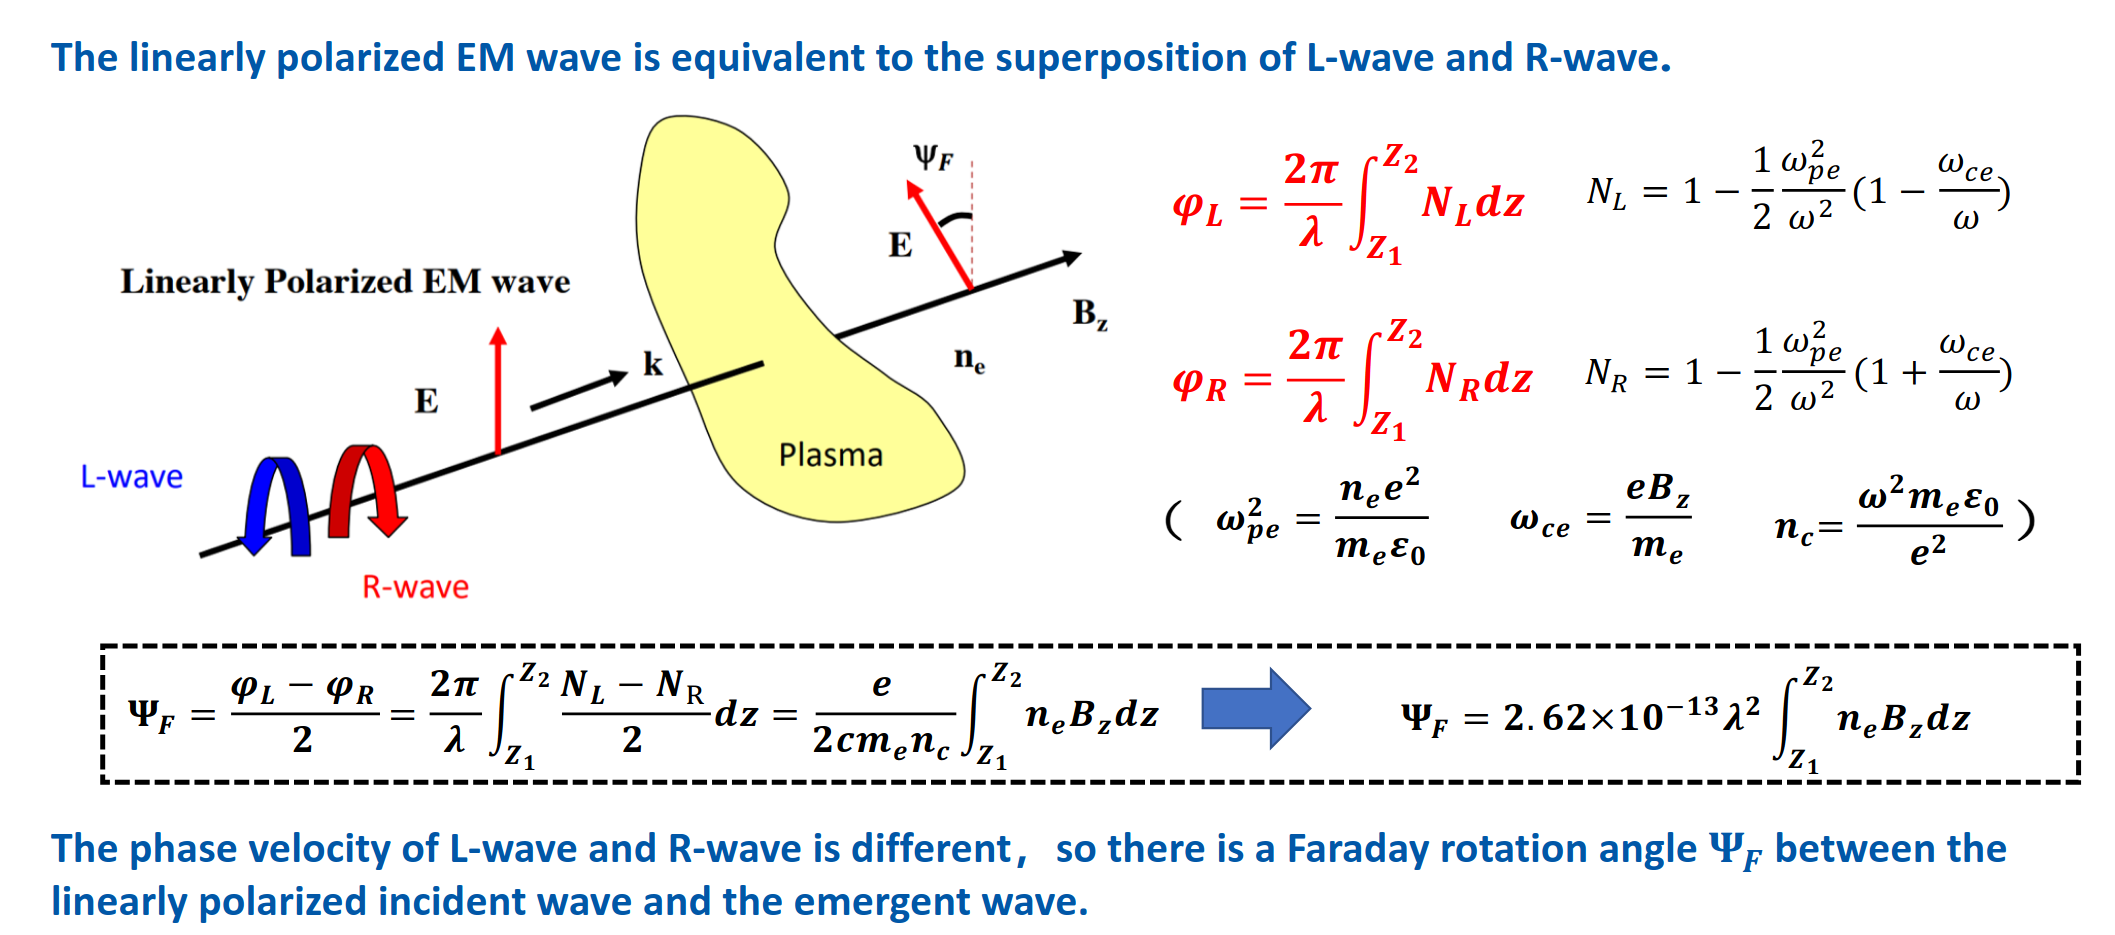

### Electron Temperature - Thomson Scattering
When shining a laser through plasma, some photons collide with electrons, creating scattered light. Because the electrons are moving, this light is doppler shifted. The scatterng of free electrons is the Thomson differential cross section. $$\frac{d\sigma}{d\Omega} = r_e^2(1+cos^2\theta) $$. Where $r_e = \frac{e^2}{4\pi \epsilon_0 m_e c^2}$, and $\theta$ is the angle between incident and scattered light. The scattered power can be described by he following $$\frac{dP_s}{d\Omega} = n_e \frac{d\sigma_T}{d\Omega}P_i $$ where the cros section $\frac{d\sigma_T}{d\Omega}= r_e^2sin^2{\phi}$. The spectrum of scatered light is a gaussian whose width leaves $T_e$: $$\Delta \omega \propto \omega_0 \sqrt{\frac{k_B T_e}{m_e c^2}} $$

In [7]:

#Constants
e    = 1.602e-19       # C
m_e  = 9.109e-31      # kg
eps0 = 8.854e-12      # F/m
c    = 2.998e8        # m/s
lambda0 = 1.06e-6     # m
omega   = 2 * np.pi * c / lambda0   # rad/s  (~1.78e15)

N  = 1000
rho = np.linspace(0, 1, N)   # ρ = r/a,  0=core, 1=edge
drho = rho[1] - rho[0]
a  = 1.0 


out = widgets.Output()

with out:
    fig, axes = plt.subplots(3, 1, tight_layout=True, figsize=(9, 9))
    fig.patch.set_facecolor('#111111')
    colors = ['#00cfff', '#ff6ec7', '#a0ff80']
    labels = ["Electron density  nₑ(ρ)",
              "Reflectometry — accumulated phase Δφ(ρ)",
              "Polarimetry — Faraday rotation Ψ(ρ)"]
    ylabels = ["nₑ  [10¹⁹ m⁻³]", "Δφ  [rad]", "Ψ  [rad]"]

    lines = []
    cutoff_lines = []
    for ax, col, lbl, ylbl in zip(axes, colors, labels, ylabels):
        ax.set_facecolor('#111111')
        ln, = ax.plot(rho, np.zeros(N), color=col, lw=2)
        cl  = ax.axvline(x=1.5, color='yellow', lw=1.2,
                         ls='--', label='cutoff layer')
        lines.append(ln)
        cutoff_lines.append(cl)
        ax.set_ylabel(ylbl)
        ax.set_xlabel("ρ  (r/a)")
        ax.set_title(lbl, pad=6)
        ax.grid(True, alpha=0.4)


    cutoff_lines[0].set_visible(False)
    cutoff_lines[2].set_visible(False)
    axes[1].legend(fontsize=12)

    plt.show()




def density_profile(n0_19, alpha):
    """
    Peaked tokamak profile:  nₑ(ρ) = n0 · (1 − ρ²)^α
    Naturally → 0 at the separatrix (ρ=1), peaked at core.
    """
    return n0_19 * 1e19 * np.clip(1 - rho**2, 0, None)**alpha


def plasma_freq_sq(n_e):
    """ωₚ²(ρ) = n_e·e² / (mₑ·ε₀)"""
    return n_e * e**2 / (m_e * eps0)


def cutoff_index(n_e):
    """
    Find first index where ωₚ ≥ ω  (O-mode cutoff).
    Returns N (no cutoff) if the laser propagates through.
    """
    wp2 = plasma_freq_sq(n_e)
    idx = np.argmax(wp2 >= omega**2)   # argmax returns 0 if never True
    if wp2[0] >= omega**2:
        return 0
    if idx == 0:
        return N   # never reaches cutoff
    return idx


def reflectometry_phase(n_e, i_cut):
    """
    Phase accumulated from ρ=0 to the cutoff layer (O-mode):
        Δφ = (ω/c) · ∫₀^ρ_cut  [1 − (ωₚ/ω)²]^½  a·dρ
    Beyond cutoff the wave is evanescent → phase stays constant.
    """
    wp2   = plasma_freq_sq(n_e)
    ratio = np.clip(wp2 / omega**2, 0, 1.0)
    n_ref = np.sqrt(1 - ratio)           # refractive index (real part)

    integrand = n_ref * (omega / c) * a  # [rad/m] × [m/ρ] → [rad/ρ]
    phase = np.cumsum(integrand * drho)

    # freeze phase beyond cutoff (wave turns around there)
    if i_cut < N:
        phase[i_cut:] = phase[i_cut - 1]

    return phase


def faraday_rotation(n_e, B0, R0):
    """
    Faraday rotation for O-mode laser along chord:
        dΨ/ds = (e³ / 8π²ε₀ mₑ² c³) · nₑ · B_∥ · λ²
    B profile: tokamak toroidal field B ∝ R0/(R0+a·ρ)  (1/R law).
    λ is the free-space wavelength.
    """
    B_parallel = B0 * R0 / (R0 + a * rho)    # [T], 1/R toroidal field

    coeff = (e**3 * lambda0**2 /
             (8 * np.pi**2 * eps0 * m_e**2 * c**3))  # [rad·m²/T]

    integrand = coeff * n_e * B_parallel * a   # [rad/ρ]
    return np.cumsum(integrand * drho)




def update(n0=5.0, alpha=1.5, B0=3.0, R0=3.0):
    n_e    = density_profile(n0, alpha)
    i_cut  = cutoff_index(n_e)
    phase  = reflectometry_phase(n_e, i_cut)
    rot    = faraday_rotation(n_e, B0, R0)

    # panel 0 — density
    lines[0].set_ydata(n_e / 1e19)
    axes[0].set_ylim(0, n0 * 1.25)
    axes[0].set_xlim(0, 1)

    # panel 1 — reflectometry phase
    lines[1].set_ydata(phase)
    axes[1].set_ylim(0, max(phase) * 1.3 + 0.1)
    axes[1].set_xlim(0, 1)
    # move cutoff marker
    rho_cut = rho[i_cut] if i_cut < N else 1.05
    cutoff_lines[1].set_xdata([rho_cut, rho_cut])
    cutoff_lines[1].set_visible(i_cut < N)

    # panel 2 — Faraday rotation
    lines[2].set_ydata(rot)
    axes[2].set_ylim(0, max(rot) * 1.3 + 1e-4)
    axes[2].set_xlim(0, 1)

    fig.canvas.draw_idle()


# Sliders
slider_style   = {'description_width': '160px'}
slider_layout  = widgets.Layout(width='480px')

sliders = dict(
    n0    = FloatSlider(value=5.0, min=0.1, max=15.0, step=0.1,
                        description='Peak density n₀ [×10¹⁹ m⁻³]',
                        style=slider_style, layout=slider_layout),
    alpha = FloatSlider(value=1.5, min=0.5, max=4.0,  step=0.1,
                        description='Profile peaking α',
                        style=slider_style, layout=slider_layout),
    B0    = FloatSlider(value=3.0, min=0.5, max=8.0,  step=0.1,
                        description='Toroidal field B₀ [T]',
                        style=slider_style, layout=slider_layout),
    R0    = FloatSlider(value=3.0, min=1.0, max=6.0,  step=0.1,
                        description='Major radius R₀ [m]',
                        style=slider_style, layout=slider_layout),
)

controls = interactive(update, **sliders)
controls.update()   # draw initial state

display(VBox([
    out,
    widgets.HTML("<hr style='border-color:#444'>"),
    controls
]))

## Some Examples of Detectors
1. Torodial Interferometer Polarimeter (TIP) - designer for ITER in France 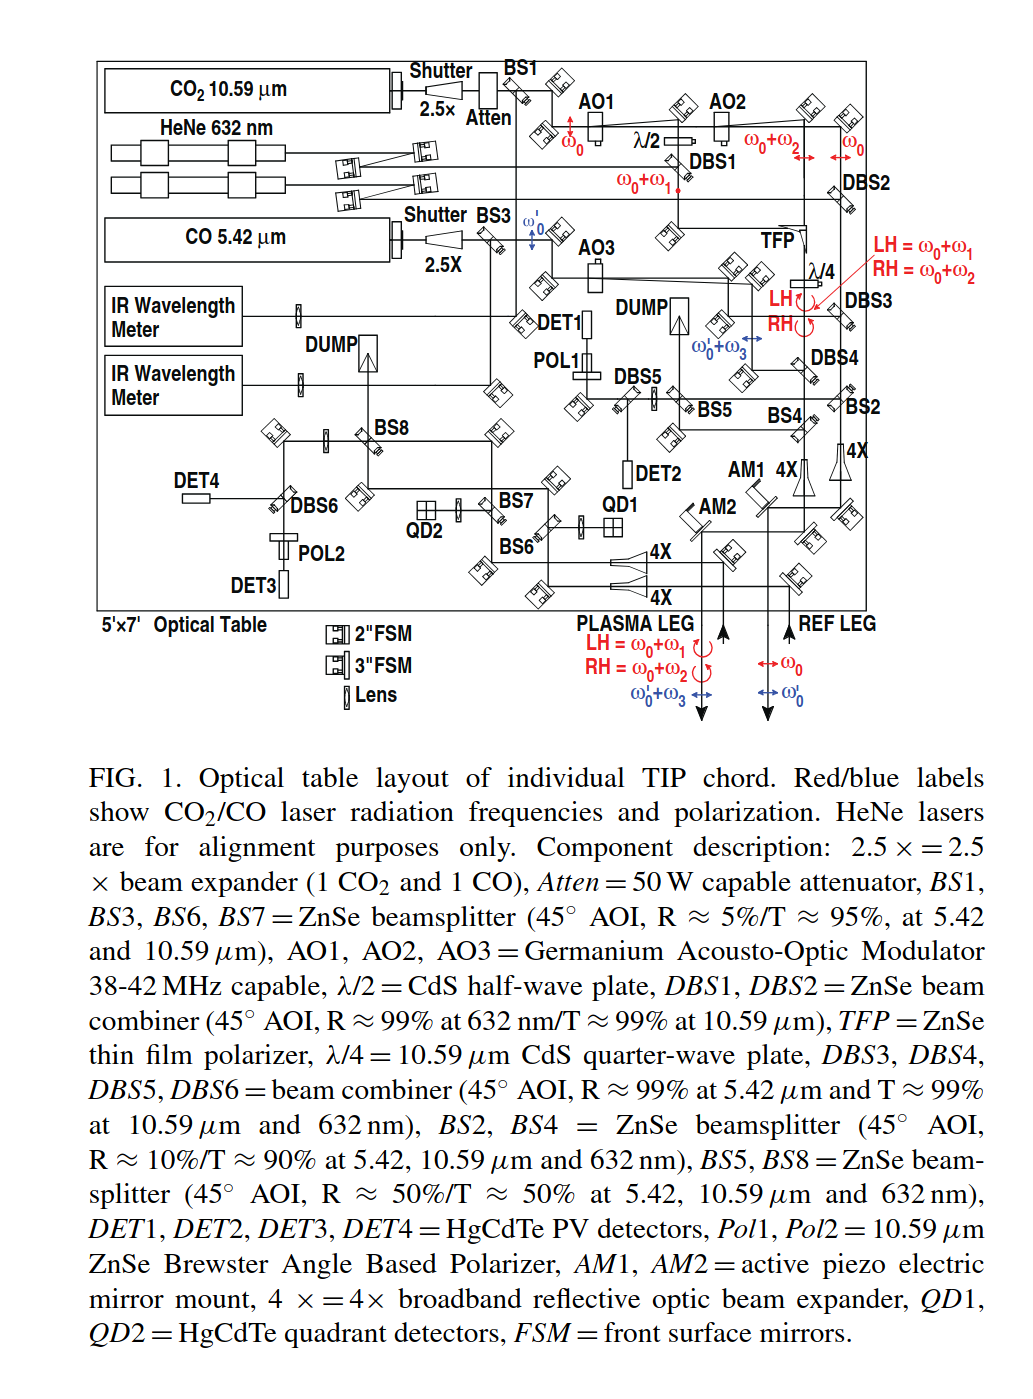 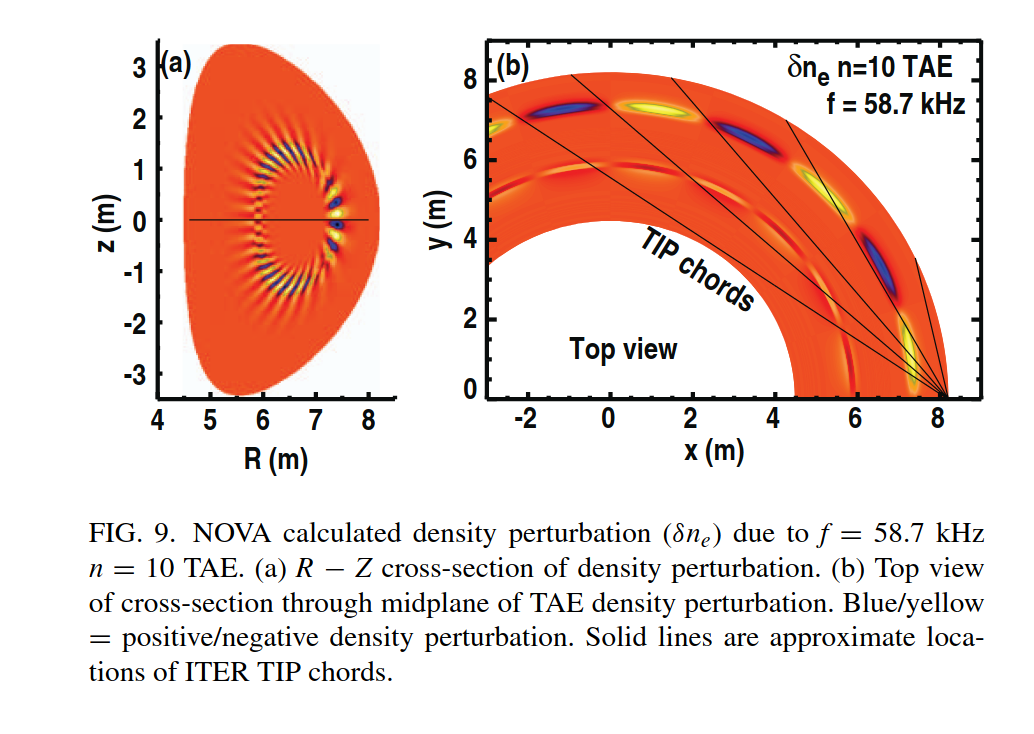
2. Thomson scattering systm in the Large Helical Device (LHD) -Nd:YAG laser capable of 20 kHz pulse rates. 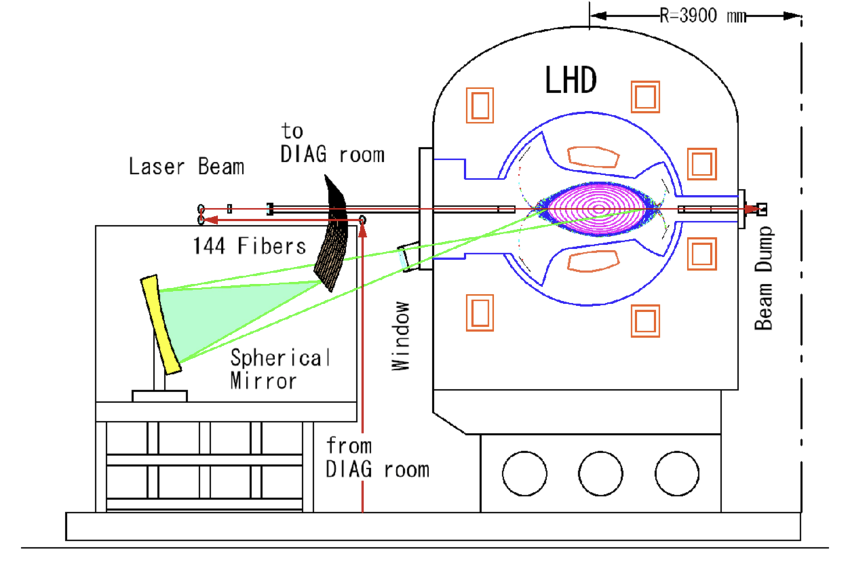
3. Two-Color Interferometer at DIII-D in San Diego- combination of CO2 and HeNe lasers
4. CO2 Laser Polarimeter - In a collaborative project between General Atomics and the Large Helical Device in Japan, a polarimeter was built to measure the electron density via measurement of the Faraday rotation angle of a linearly polarized CO2 laser.


### References
Hutchinson, I. H.  
   *Principles of Plasma Diagnostics* (2nd ed.).  
   Springer, 2002.  
   https://link.springer.com/book/10.1007/978-3-319-22309-4
   
ITER Organization.  
   *Introduction to Polarimetry and Interferometry in ITER*.  
   ITER International School, Nagoya (2024).  
   https://www.iter.org/sites/default/files/media/2024-12/     
   l10_ding_iter_school_int_pol_nagoya2024.pdf  
   
U.S. Department of Energy.  
   *DOE Explains... Tokamaks*.  
   https://www.energy.gov/science/doe-explainstokamaks  
   
General Atomics.  
   *Laser-Based Plasma Diagnostics*.  
   https://www.ga.com/center-of-excellence/advanced-diagnostics/  
   laser-based-plasma-diagnostics  
   
National Laboratories / OSTI.  
   *Advanced Plasma Diagnostics and Measurement Techniques*.  
   https://www.osti.gov/pages/servlets/purl/2423839 
   
Review of Scientific Instruments (AIP Publishing).  
   *Laser-based plasma diagnostic techniques* (article).  
   https://watermark02.silverchair.com/043501_1_online.pdf  

Funaba, H., Yasuhara, R., Uehara, H. et al. Electron temperature and density measurement by Thomson scattering with a high repetition rate laser of 20 kHz on LHD. Sci Rep 12, 15112 (2022). https://doi.org/10.1038/s41598-022-19328-9